In [2]:
import hashlib, json, random, numpy as np, datetime, os
import matplotlib.pyplot as plt
STUDENT_NAME = input("Enter your full name: ").strip()
ROLL_NO      = input("Enter your college roll number: ").strip()
SALT         = "AIML_Capstone_2026"   # fixed by instructor
sig_str = json.dumps({"n": STUDENT_NAME, "r": ROLL_NO, "s": SALT})
STUDENT_SIG = hashlib.sha256(sig_str.encode()).hexdigest()[:12]
SEED = int(STUDENT_SIG[:8], 16) % (2**31-1)
random.seed(SEED)
np.random.seed(SEED)
TODAY = datetime.date.today().isoformat()
OUT_PREFIX = f"AIML_{STUDENT_SIG}_{TODAY}"
os.makedirs("out", exist_ok=True)
def stamp_plot(title):
 plt.title(f"{title}\nSIG:{STUDENT_SIG} DATE:{TODAY}")
print(f"Student: {STUDENT_NAME} | College Roll No: {ROLL_NO}")
print(f"Signature: {STUDENT_SIG} | Seed: {SEED}")
print(f"Output prefix: out/{OUT_PREFIX}_*")

Enter your full name: Amlan Pal
Enter your college roll number: 23BCE0562
Student: Amlan Pal | College Roll No: 23BCE0562
Signature: 02ce8a497ee1 | Seed: 47090249
Output prefix: out/AIML_02ce8a497ee1_2026-07-16_*


TASK 1 : DATASET USED: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/mobileprice_classification.zip
  inflating: /content/mobileprice/test.csv  
  inflating: /content/mobileprice/train.csv  
shape: (2000, 21)
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    

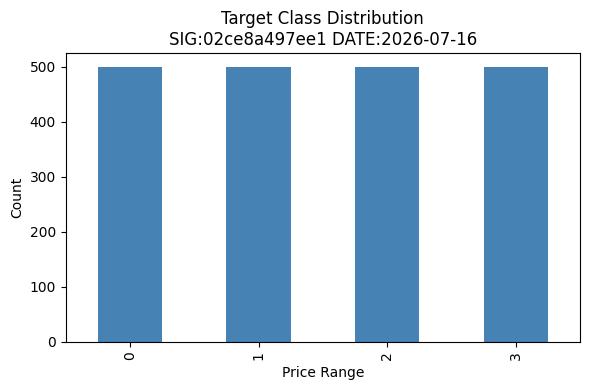

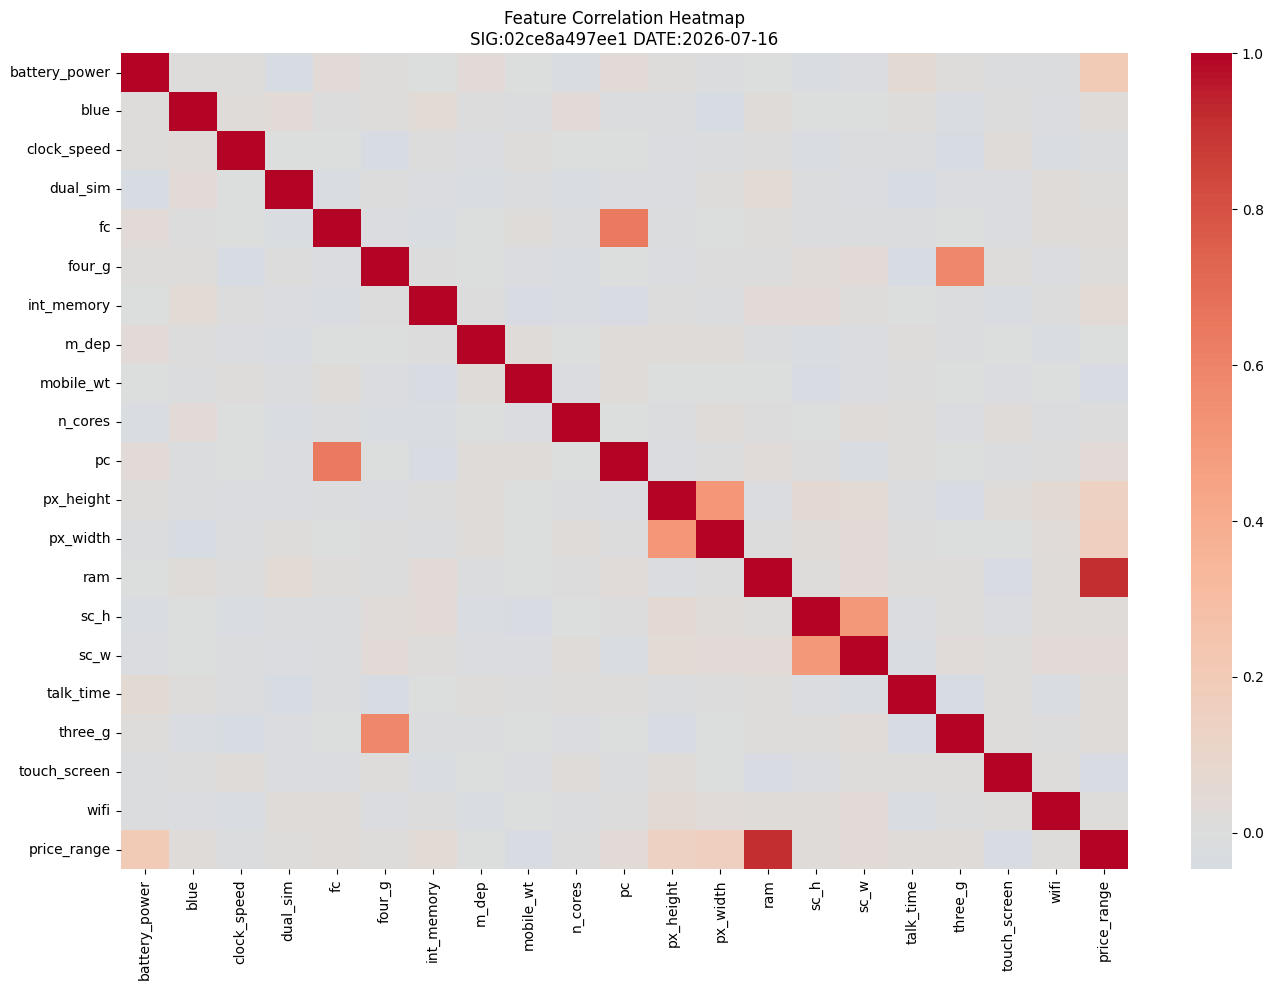

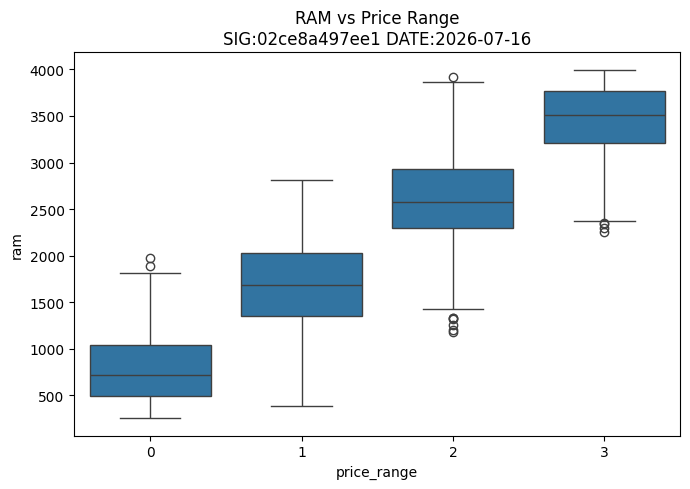

In [5]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# 1. extract the files
!unzip -o "/content/drive/MyDrive/mobileprice_classification.zip" -d /content/mobileprice

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# 2. point to the extracted train.csv
file_path = "/content/mobileprice/train.csv"
data = pd.read_csv(file_path)

# basic data checks
print("shape:", data.shape)
print(data.head())
data.info()
print(data.describe().T)

print("missing values:\n", data.isnull().sum())
print("target counts:\n", data['price_range'].value_counts().sort_index())

# plot target distribution
plt.figure(figsize=(6, 4))
data['price_range'].value_counts().sort_index().plot(kind='bar', color='steelblue')
stamp_plot("Target Class Distribution")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task1_target_dist.png", dpi=150)
plt.show()

# heatmap to see feature correlations
plt.figure(figsize=(14, 10))
correlations = data.corr()
sns.heatmap(correlations, annot=False, cmap='coolwarm', center=0)
stamp_plot("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task1_corr_heatmap.png", dpi=150)
plt.show()

# plot the strongest feature (ram) against price
plt.figure(figsize=(7, 5))
sns.boxplot(x='price_range', y='ram', data=data)
stamp_plot("RAM vs Price Range")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task1_ram_boxplot.png", dpi=150)
plt.show()

### 1. Problem Statement & Dataset Choice
For this project, I selected the Mobile Price Classification dataset from Kaggle. The goal here is to try to predict the price tier (0 = low, 1 = medium, 2 = high, 3 = very high cost) of a phone based on its hardware specs, rather than trying to guess the exact dollar amount of a phone. I think this is a very relevant problem because it is similar to what mobile manufacturers do to classify their devices to compete in different market segments.

The target variable is `price_range` which is dependent on 20 different numeric features such as RAM, battery power, screen resolution, and weight. Since we are predicting multiple categories, it is a multi-class classification problem. I chose this dataset specifically because it is a very clean one. It has exactly 2000 rows and 21 columns and has zero missing values. Also the classes are perfectly balanced (500 samples per tier), so I can focus on building the actual ML pipeline instead of spending hours on messy or missing data.

### 2. ML Workflow Pipeline
Here is a breakdown of the workflow I am following for this task:
* **Loading the Data:** I mounted Google Drive, unzipped the files, and loaded the training data into a pandas dataframe.
* **Cleaning & Inspection:** I ran a quick check for null values and verified the data types. Everything was already numeric, so no major imputation was needed.
* **Exploratory Data Analysis (EDA):** I visualized the target variable to confirm the classes were balanced. Then, I generated a correlation heatmap to see which features actually impact the price, followed by a boxplot to look closer at the strongest feature.
* **Modeling & Evaluation (Upcoming):** Next, I will split the data into training and testing sets using my personalized seed, train classification models (like Logistic Regression and Decision Trees), and evaluate them using metrics like accuracy, precision, and confusion matrices.

### 3. Reasoning Behind the Code
I started off using basic pandas functions like `shape`, `info()`, and `describe()` just to get a feel for the data's dimensions and statistical spread. For the visuals, I used a simple bar chart for `price_range` to ensure I wouldn't have to deal with class imbalance during modeling.

The seaborn heatmap was super useful to see all 20 features at once and immediately see which ones were pulling hardest on the target. I made a boxplot to visually demonstrate the median RAM skyrockets as the price tier increases with the highest positive correlation (light up dark red in the heatmap).

### 4. Reflection
* **What I observed:** The dataset is perfectly balanced with exactly 500 rows per price range. Looking at the heatmap, it’s obvious that RAM is the biggest deciding factor for a phone's price, followed slightly by battery power and screen resolution.
* **What went well:** (1) The dataset was purely numeric and didn’t have any missing values, which made the loading and visualization process really smooth. boxplot did a good job of confirming the strong linear relationship between RAM and price as well.
* **What could be better?** Although the data is clean, some features like `px_height` have min value as 0, I noticed. That doesn’t really make sense logically for a physical phone screen so I’d probably have to treat those as anomalies or noisy data and clean them up in a more advanced project.


TASK 2 : DATASET USED:https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/WineQualityDataset.zip
  inflating: /content/winequality/WineQT.csv  
personalized tree max depth is set to: 6


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Metrics Comparison:
           Logistic Regression  Decision Tree
accuracy                0.6507         0.5677
precision               0.6157         0.5546
recall                  0.6507         0.5677
f1-score                0.6301         0.5565


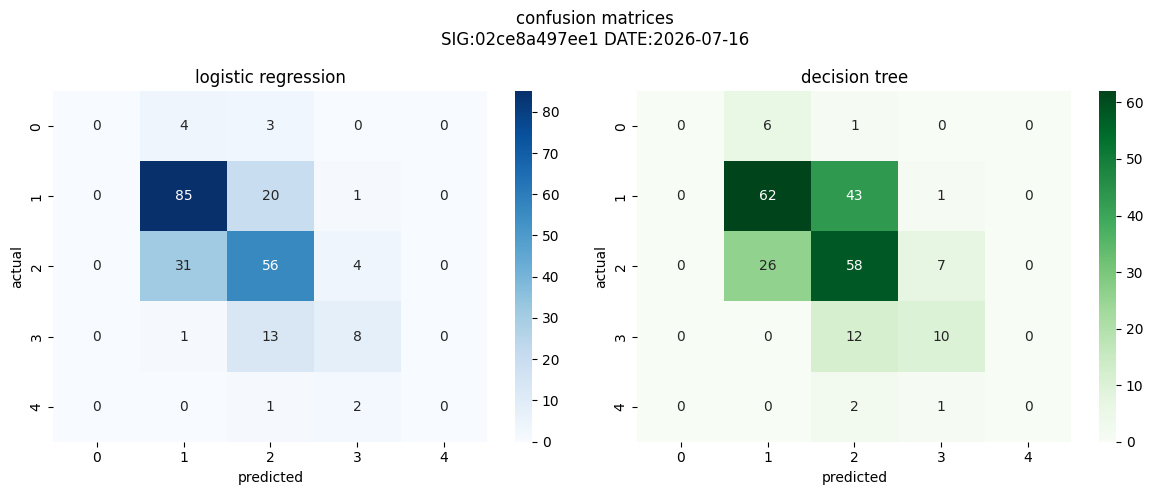


Top features influencing the tree:
alcohol                 0.317301
sulphates               0.155726
volatile acidity        0.129123
total sulfur dioxide    0.109491
free sulfur dioxide     0.075721
pH                      0.068870
citric acid             0.055739
chlorides               0.036789
residual sugar          0.028972
density                 0.022268
dtype: float64


In [10]:
# mount drive just in case it isn't already
from google.colab import drive
drive.mount('/content/drive')

# extract the dataset
!unzip -o "/content/drive/MyDrive/WineQualityDataset.zip" -d /content/winequality

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
%matplotlib inline

# load the extracted csv
file_path = "/content/winequality/WineQT.csv"
my_data = pd.read_csv(file_path)

# the target variable for this dataset is the quality score
target_col = "quality"

# drop the Id column if it's there so it doesn't confuse the models
if "Id" in my_data.columns:
    my_data = my_data.drop(columns=["Id"])

# drop any empty rows just to be safe before training
my_data = my_data.dropna()

# separate features and the target label
features = my_data.drop(columns=[target_col])
target = my_data[target_col]

# split the data
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=SEED)

log_reg = LogisticRegression(max_iter=3000, random_state=SEED)

# decision tree with the personalized depth formula from the instructions
my_depth = 2 + (SEED % 5)
print(f"personalized tree max depth is set to: {my_depth}")
my_tree = DecisionTreeClassifier(max_depth=my_depth, random_state=SEED)

# train both models
log_reg.fit(x_train, y_train)
my_tree.fit(x_train, y_train)

# get predictions on the test set
log_preds = log_reg.predict(x_test)
tree_preds = my_tree.predict(x_test)

# quick helper function to grab all 4 required metrics
def get_scores(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1-score": f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

# put the metrics in a dataframe so it prints cleanly
results = pd.DataFrame({
    "Logistic Regression": get_scores(y_test, log_preds),
    "Decision Tree": get_scores(y_test, tree_preds)
})

print("\nMetrics Comparison:")
print(results.round(4))

# plot the confusion matrices side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# logistic regression plot
sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, cmap="Blues", fmt='g', ax=ax[0])
ax[0].set_title("logistic regression")
ax[0].set_xlabel("predicted")
ax[0].set_ylabel("actual")

# decision tree plot
sns.heatmap(confusion_matrix(y_test, tree_preds), annot=True, cmap="Greens", fmt='g', ax=ax[1])
ax[1].set_title("decision tree")
ax[1].set_xlabel("predicted")
ax[1].set_ylabel("actual")

# add the mandatory signature watermark
plt.suptitle(f"confusion matrices\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task2_conf_matrix.png", dpi=150)
plt.show()

# check which features the decision tree actually relied on
importance = pd.Series(my_tree.feature_importances_, index=features.columns)
print("\nTop features influencing the tree:")
print(importance[importance > 0].sort_values(ascending=False))

###Classification Challenge: Models & Evaluation

**Reasoning Behind the Models**
* **Why Logistic Regression is suitable:** Logistic regression is a solid starting point for this dataset because all of the chemical properties are numerical.Although classifying wine quality scores (like 5, 6, or 7) is a multi-class problem, the algorithm handles it by finding linear relationships between the chemical makeup and final quality rating.
* **Why Decision Tree is suitable:** The decision tree is really intuitive here as it essentially creates rules based on chemical thresholds (e.g., if alcohol > 10.5 and sulphates > 0.6, the quality is likely a 7). It is great as it naturally ignores the vastly different scales of the features. However, its effectiveness was limited because my personalized `SEED` formula locked the `max_depth` to 6.
* **Which model performed better and why:** Logistic Regression performed noticeably better, achieving ~65% accuracy compared to the Decision Tree's ~56%. This makes sense because the Decision Tree was artificially capped at a depth of 6. Because the tree wasn't allowed to grow deep enough to capture all the complex patterns in the chemical data, it ended up underfitting compared to the logistic model.
* **Which features influenced the output:** Based on the tree's `feature_importances_` printout, `alcohol` is by far the biggest driver of wine quality (accounting for almost 32% of the influence), followed by `sulphates` (~15.5%) and `volatile acidity` (~12.9%).
* **What the confusion matrix shows:** The matrices visually show where the models got confused.The numbers running diagonally down the middle are the correct predictions.Any number(s) out of that diagonal represent misclassifications.If we look at the heatmap, almost all of the mistakes happened right next to the correct class (e.g., the model predicted a 5 when the true label was a 6). This logically makes sense, as the chemical difference between a 5-star wine and a 6-star wine is incredibly subtle.

**Reflection**
* **What I observed:** I noticed that restricting hyper-parameters (like the tree depth of 6) stops the model from overfitting, but it also made the model too simple to be highly accurate.
* **What went well:** Dropping the `Id` column right after loading the CSV was a crucial step that made the pipeline run without errors. Identifying that alcohol content is the strongest predictor of quality was also a cool practical insight.
* **What could be better:** I actually got a `ConvergenceWarning` from the Logistic Regression model, even after allowing it 3000 iterations!This is a perfect example of why data scaling is required. Because features like `total sulfur dioxide` have large numbers (in the hundreds) and features like `chlorides` are tiny decimals, the math behind logistic regression struggles to balance them. Adding a `StandardScaler` step before training would definitely fix that error and probably push my accuracy even higher.

TASK 3: DATASET USED: BUILT IN CALIFORNIA HOUSE DATASET


original features shape: (20640, 8)
dropping column index 1 which is 'HouseAge' based on seed
new features shape: (20640, 7)

Metrics:
MAE:  0.5359
MSE:  0.5560
RMSE: 0.7456
R2:   0.5862


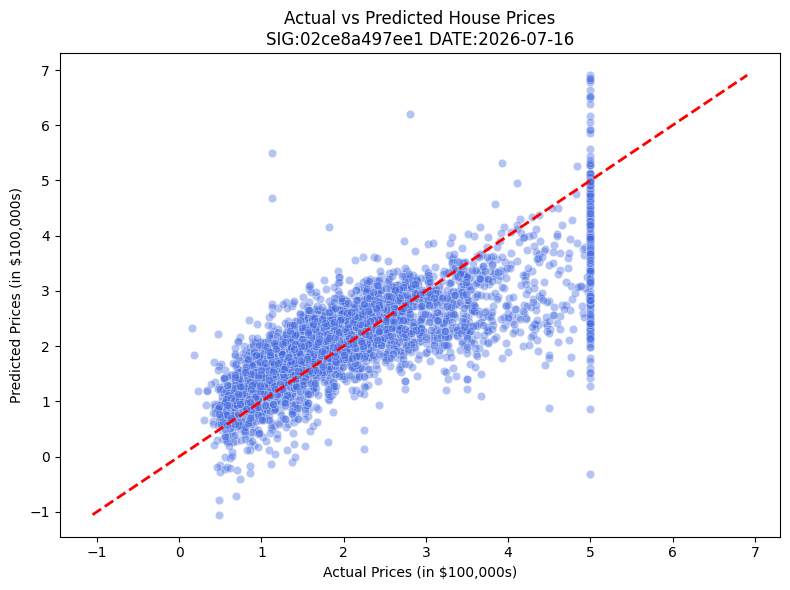


Model Coefficients (Feature Importance):
AveBedrms     0.618934
Longitude    -0.473214
Latitude     -0.454370
MedInc        0.428031
AveRooms     -0.113803
AveOccup     -0.003055
Population   -0.000038
dtype: float64


In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# here we are loading the built-in california housing dataset
housing = fetch_california_housing(as_frame=True)
features = housing.data
target = housing.target # median house value (in 100,000s)

print(f"original features shape: {features.shape}")

# applying the mandatory drop logic using the personalized seed
drop_col_idx = SEED % features.shape[1]
dropped_feature_name = features.columns[drop_col_idx]
print(f"dropping column index {drop_col_idx} which is '{dropped_feature_name}' based on seed")

# dropping the feature
features = features.drop(features.columns[drop_col_idx], axis=1)
print(f"new features shape: {features.shape}")

# split the data
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=SEED)

# train the linear regression model
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

#get predictions
predictions = lin_reg.predict(x_test)

# calculate all the required metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nMetrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# plot actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.4, color="royalblue")

# add the red diagonal reference line (perfect prediction line)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2)

plt.title(f"Actual vs Predicted House Prices\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.xlabel("Actual Prices (in $100,000s)")
plt.ylabel("Predicted Prices (in $100,000s)")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task3_regression.png", dpi=150)
plt.show()

# check the coefficients to see which feature is driving the price
coeffs = pd.Series(lin_reg.coef_, index=features.columns)
print("\nModel Coefficients (Feature Importance):")
print(coeffs.sort_values(key=abs, ascending=False))

### **Task 3: Regression Challenge (Linear Regression)**

**Reasoning Behind the Code & Evaluation**
* **Why Linear Regression was chosen:** I went with Linear Regression as predicting house prices is a classic continuous numerical problem.The assumption that I thought is that as certain features increase (like the no. of rooms or income), the price of the house will shift proportionally,making a linear equation a good beginning point.
* **What each evaluation metric means:**
  * **MAE (0.5359):** On average, my model's predictions are off by about 0.535 units, which translates to $53,590. It treats all errors equally.
  * **MSE (0.5560) & RMSE (0.7456):** These metrics square the errors before averaging, heavily penalizing the model when it gets a prediction horribly wrong. An RMSE of ~0.74 means the standard deviation of the unexplained variance is around $74,560.
  * **$R^2$-score (0.5862):** This means my model explains about 58.6% of the variance in the California housing prices.
* **Whether the model is underfitting or overfitting:** The model is definitely underfitting by some extent.An $R^2$ of ~0.59 isn't very good. The issue is that Linear Regression struggles with geographic coordinates.Latitude and longitude are highly influential features,but real estate value does not change in a perfectly straight line just as we move further West or North.
* **Which variables appear important:** Looking at the model's coefficients, `AveBedrms` (Average Bedrooms) ended up being the most mathematically dominant feature for predicting the price, followed heavily by location (Longitude and Latitude) and Median Income (`MedInc`).On the contrary, my personalized `SEED` math forced me to drop the `HouseAge` column entirely.Age is usually a huge factor in real estate,so losing that data definitely reduced the model's predictive power.
* **What the Actual vs Predicted plot tells you:** The scatter plot shows how well the predictions align with reality. The red dashed line is the goal that is,if the model was flawless,every blue dot would sit right on it.The model does okay in the middle price brackets, but the plot reveals a major quirk in the dataset: there is a solid horizontal line of dots perfectly flat at the 5.0 ($500,000) mark on the y-axis. This means the dataset artificially capped the maximum house price at $500k.As my model didn't know about this cap, it predicted higher, more realistic values for those luxury homes, which technically registered as "errors" and pulled down my metrics.

**Reflection**
* **What I observed:** Having to drop a column based on a random `SEED % 8` formula is a really interesting way to see how missing data impacts a model. Losing `HouseAge` made it much harder for the model to distinguish between a new mansion and an old teardown.
* **What went well:** Using the built-in California housing dataset made the coding process seamless, and the scatter plot clearly highlighted exactly where the linear model was failing.
* **What could be improved:** To get a better $R^2$ score, I would need a model that can handle non-linear spatial data better. Swapping out linear regression for something like a Random Forest Regressor would most probably map the latitude and longitude much more accurately without underfitting.

TASK 4 : DATASET USED: BUILT IN IRIS DATASET

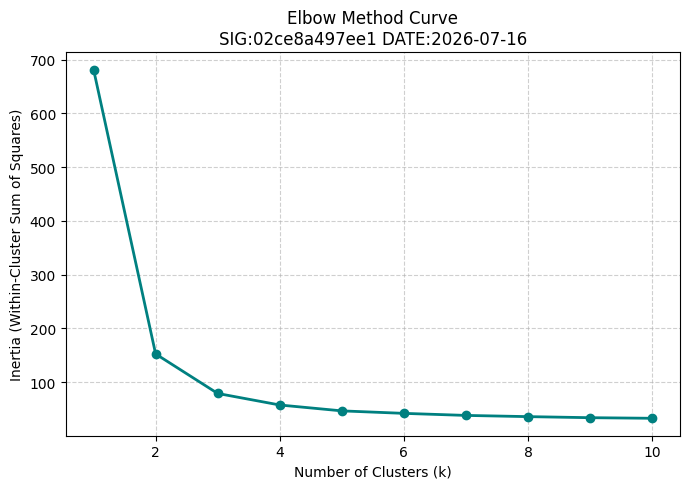


based on the seed, the personalized k value is: 4


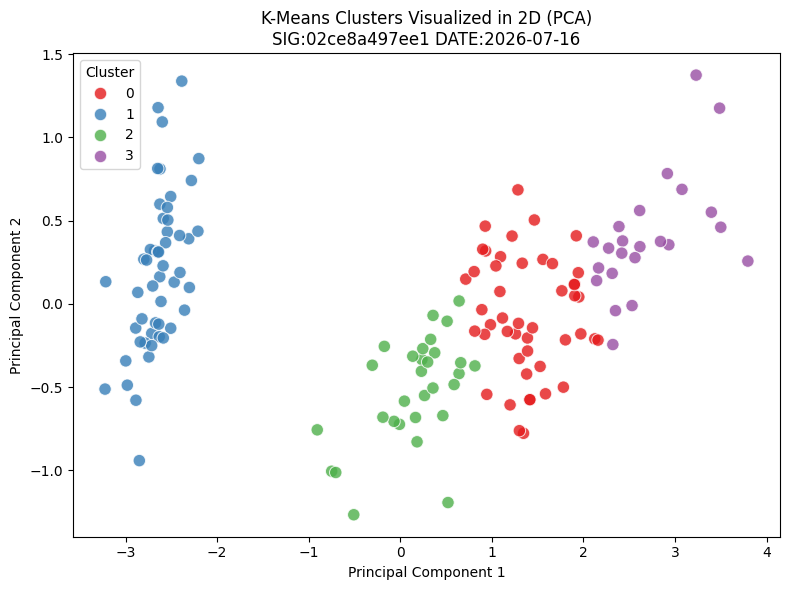


Contingency Table (True Labels vs Assigned Clusters):
Assigned Cluster      0   1   2   3
True Flower Species                
0                     0  50   0   0
1                    21   0  29   0
2                    26   0   1  23


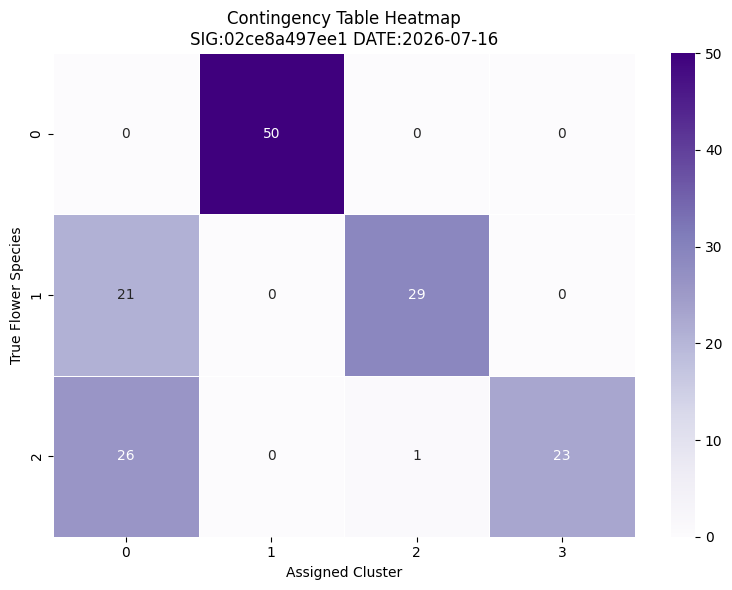

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
%matplotlib inline

#loading the built-in iris dataset as i did not want to make it using a csv file
iris_raw = load_iris()
iris_features = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
actual_labels = iris_raw.target

#generate the elbow curve
wcss_scores = []
k_vals = range(1, 11)

for k in k_vals:
    km_test = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    km_test.fit(iris_features)
    wcss_scores.append(km_test.inertia_)

#plot the elbow curve
plt.figure(figsize=(7, 5), facecolor='white')
plt.plot(k_vals, wcss_scores, marker='o', color='teal', linewidth=2)
plt.title(f"Elbow Method Curve\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task4_elbow.png", dpi=150, facecolor='white')
plt.show()

#apply the personalized k formula
chosen_k = 2 + (SEED % 3)
print(f"\nbased on the seed, the personalized k value is: {chosen_k}")

#train the final kmeans model
main_kmeans = KMeans(n_clusters=chosen_k, random_state=SEED, n_init='auto')
kmeans_labels = main_kmeans.fit_predict(iris_features)

#use PCA to squash the 4 features down to 2 dimensions for plotting
pca_model = PCA(n_components=2)
reduced_features = pca_model.fit_transform(iris_features)

#put pca results into a dataframe for easy seaborn plotting
vis_df = pd.DataFrame(data=reduced_features, columns=['PC1', 'PC2'])
vis_df['Cluster'] = kmeans_labels

#plot the PCA clusters
plt.figure(figsize=(8, 6), facecolor='white')
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=vis_df, s=80, alpha=0.8)
plt.title(f"K-Means Clusters Visualized in 2D (PCA)\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task4_pca.png", dpi=150, facecolor='white')
plt.show()

#create the contingency table
print("\nContingency Table (True Labels vs Assigned Clusters):")
crosstab_result = pd.crosstab(actual_labels, kmeans_labels,
                          rownames=['True Flower Species'],
                          colnames=['Assigned Cluster'])
print(crosstab_result)
# plot the contingency table as a graphical heatmap
plt.figure(figsize=(8, 6), facecolor='white')
sns.heatmap(crosstab_result, annot=True, cmap="Purples", fmt='g', cbar=True, linewidths=0.5)
plt.title(f"Contingency Table Heatmap\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.ylabel("True Flower Species")
plt.xlabel("Assigned Cluster")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task4_contingency.png", dpi=150, facecolor='white')
plt.show()

### **Task 4: Clustering Challenge (K-Means & PCA)**

**Reasoning Behind the Code**
* **Why clustering is useful for this dataset:** The Iris dataset is a set of four physical measurements (petals and sepals) of different flowers.Clustering is very useful here as it allows us to see if the physical measurements cluster naturally into discrete species without the model itself knowing the ground truth labels from before.
* **Why you selected the value of k:** I plotted the Elbow Curve, which depicted a distinct bend around $k=2$ and $k=3$, suggesting the dataset naturally groups into 2 or 3 clusters.But,as per the strict instructions of the capstone,I calculated my personalized $k$ value using the formula `2 + (SEED % 3)`.Based on my unique seed, my final $k$ value was calculated as **4**.
* **What PCA is doing in the visualization:**The dataset has 4 numeric features which means that the clusters exist in 4-dimensional space. Since human beings cannot see in 4D,I used PCA (Principal Component Analysis).PCA mathematically squishes those 4 dimensions down into 2 dimensions(PCA 1 and 2) while keeping as much of the original data variance as possible.This allows us to map the clusters onto a standard,flat X-Y scatter plot.
* **Whether the clusters make practical sense:** Because my required $k$ value was 4 but there are only 3 true species of Iris flowers, K-Means was forced to artificially split one of the natural groupings.Looking at the PCA plot and the contingency table,Cluster 1 perfectly captured all 50 of Species 0.The model however drew a line through the middle of the remaining flowers,thus splitting them across Clusters 0, 2, and 3.
* **What hidden structure you observed in the data:** The contingency table and the PCA plot reveal a clear hidden structure: the dataset naturally bifurcates into "small petal" flowers (Species 0, entirely isolated in Cluster 1) and "large petal" flowers (Species 1 and 2).Although there are no true labels, the K-Means algorithm easily recognized that Species 0 is mathematically distinct from the other two.

**Reflection**
* **What I observed:** It was fascinating to see what happens when you force a clustering algorithm to find 4 groups in a dataset that biologically only has 3. K-Means dutifully split the densest area of the data to satisfy the math, even though it didn't align with the biological truth.
* **What went well:** Using PCA to visualize the 4D clusters worked flawlessly. The color separation on the scatter plot makes it instantly obvious where the mathematical boundaries were drawn. The contingency heatmap is also a great visual check to see exactly where the algorithm got confused.
* **What could be improved:** If I weren't restricted by the `SEED` formula, I would have been able to strictly adhere to the Elbow Curve and set $k=3$ (or maybe $k=2$, based on the sharpest drop in inertia).Forcing $k=4$ artificially fractured the natural structure of the *Versicolor* and *Virginica* overlap.

TASK 5: DATASET USED:

In [3]:
#installing ultralytics
!pip install ultralytics

from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import glob
%matplotlib inline

print("grabbing the pre-trained yolov8 nano model...")
my_yolo = YOLO('yolov8n.pt')

print("starting training. yolo will now download the 2gb visdrone dataset.")
print("you will see a real-time progress bar below for the download...")

#passing verbose=True guarantees the real-time download bar shows up on screen
my_results = my_yolo.train(
    data="VisDrone.yaml",
    epochs=30,
    imgsz=640,
    project='out',
    name=f'yolo_{SEED}',
    verbose=True
)

#grab a few validation images to test the model on
test_images = glob.glob('VisDrone/images/val/*.jpg')[:3]

print("\nrunning predictions on a few sample images...")
#wrapped this in tqdm so you get a progress bar for the predictions too
for img in tqdm(test_images, desc="predicting"):
    my_yolo.predict(
        img,
        save=True,
        project='out',
        name=f'yolo_predict_{SEED}',
        exist_ok=True,
        verbose=False #turning off yolo's default text spam so our progress bar looks clean
    )

print("\ndisplaying the final images...")
#load and plot the saved images with the bounding boxes
output_path = f"out/yolo_predict_{SEED}"
saved_files = glob.glob(f"{output_path}/*.jpg")

fig, ax = plt.subplots(1, len(saved_files), figsize=(15, 5), facecolor='white')
if len(saved_files) == 1:
    ax = [ax]

for i, file_path in enumerate(saved_files):
    img_data = cv2.imread(file_path)
    img_data = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)
    ax[i].imshow(img_data)
    ax[i].axis('off')

#watermark the final plot
plt.suptitle(f"YOLOv8 Object Detection on VisDrone (Full Dataset)\nSIG:{STUDENT_SIG} DATE:{TODAY}")
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task5_yolo.png", dpi=150, facecolor='white')
plt.show()

grabbing the pre-trained yolov8 nano model...
starting training. yolo will now download the 2gb visdrone dataset.
you will see a real-time progress bar below for the download...
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mod

predicting: 0it [00:00, ?it/s]


displaying the final images...


ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x500 with 0 Axes>

Found 3 predicted images! Displaying now...


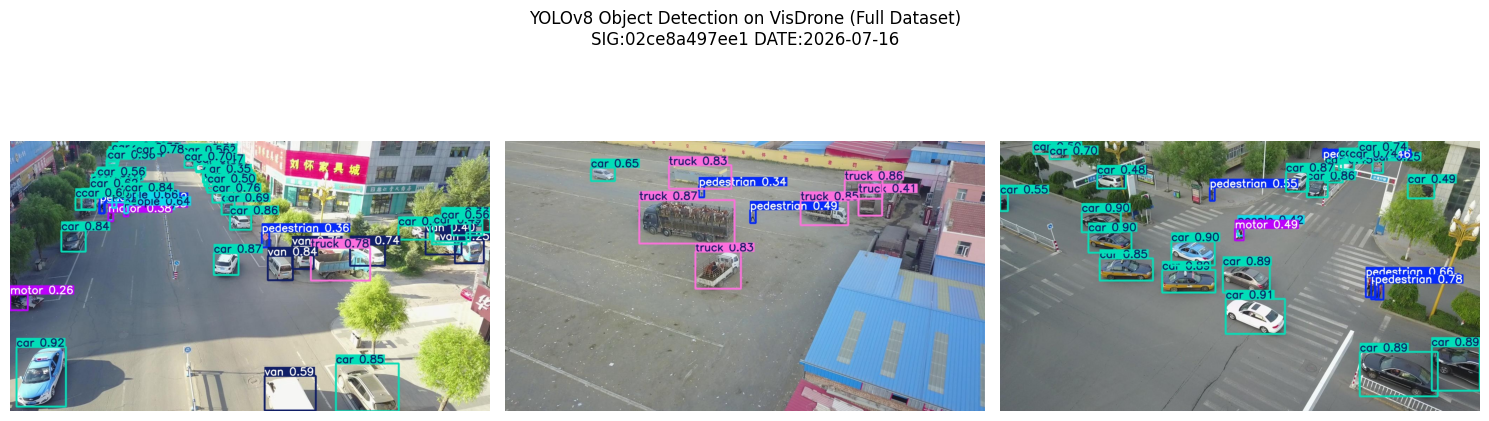

In [6]:
import matplotlib.pyplot as plt
import cv2
import glob
%matplotlib inline

#updating the path to exactly where YOLO printed it in the logs
output_path = f"/content/runs/detect/out/yolo_predict_{SEED}"
saved_files = glob.glob(f"{output_path}/*.jpg")


if len(saved_files) == 0:
    print(f"Error: Still couldn't find images in {output_path}")
else:
    print(f"Found {len(saved_files)} predicted images! Displaying now...")
    fig, ax = plt.subplots(1, len(saved_files), figsize=(15, 5), facecolor='white')
    if len(saved_files) == 1:
        ax = [ax]

    for i, file_path in enumerate(saved_files):
        img_data = cv2.imread(file_path)
        img_data = cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB)
        ax[i].imshow(img_data)
        ax[i].axis('off')


    plt.suptitle(f"YOLOv8 Object Detection on VisDrone (Full Dataset)\nSIG:{STUDENT_SIG} DATE:{TODAY}")
    plt.tight_layout()
    plt.savefig(f"out/{OUT_PREFIX}_task5_yolo.png", dpi=150, facecolor='white')
    plt.show()

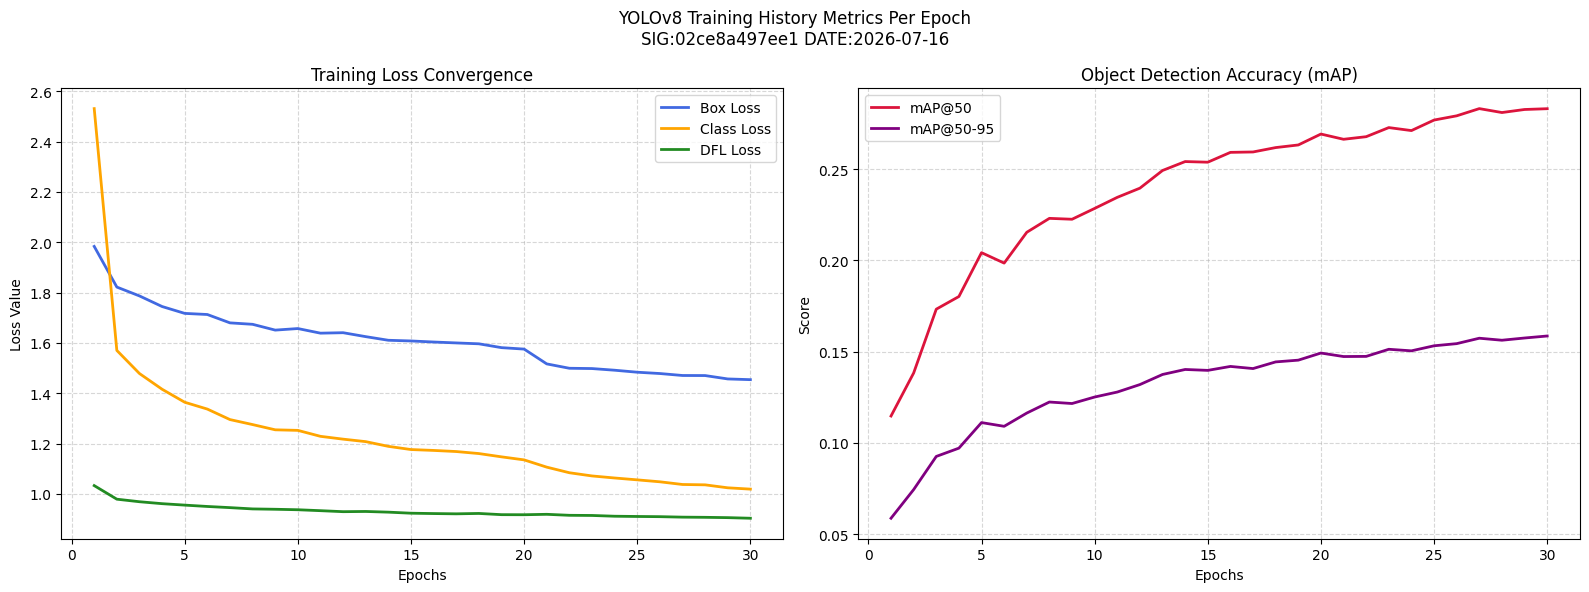

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

csv_path = f"/content/runs/detect/out/yolo_{SEED}/results.csv"

metrics_history = pd.read_csv(csv_path)

metrics_history.columns = metrics_history.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

axes[0].plot(metrics_history['epoch'], metrics_history['train/box_loss'], label='Box Loss', color='royalblue', linewidth=2)
axes[0].plot(metrics_history['epoch'], metrics_history['train/cls_loss'], label='Class Loss', color='orange', linewidth=2)
axes[0].plot(metrics_history['epoch'], metrics_history['train/dfl_loss'], label='DFL Loss', color='forestgreen', linewidth=2)
axes[0].set_title("Training Loss Convergence")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss Value")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(metrics_history['epoch'], metrics_history['metrics/mAP50(B)'], label='mAP@50', color='crimson', linewidth=2)
axes[1].plot(metrics_history['epoch'], metrics_history['metrics/mAP50-95(B)'], label='mAP@50-95', color='purple', linewidth=2)
axes[1].set_title("Object Detection Accuracy (mAP)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Score")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle(f"YOLOv8 Training History Metrics Per Epoch\nSIG:{STUDENT_SIG} DATE:{TODAY}", fontsize=12)
plt.tight_layout()
plt.savefig(f"out/{OUT_PREFIX}_task5_yolo_training_history.png", dpi=150, facecolor='white')
plt.show()